# Food101: Surpassing Research Benchmarks with EfficientNetB0
**Author:** Puneet Sharma  
**Objective:** To outperform the [DeepFood (2016)](https://www.researchgate.net/publication/304163308_DeepFood) benchmark of **77.4%** accuracy using a modern, efficient architecture and optimized data pipeline.


## The Strategy
1. **Feature Extraction:** Establishing a baseline with a frozen backbone.
2. **Fine-Tuning:** Unfreezing the full architecture for class-specific adaptation.
3. **Data Augmentation:** implementing a high-speed CPU-bound pipeline to prevent overfitting.
4. **Regularization:** Using Dropout (0.3) to reach peak validation stability.

## Imports

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision, layers, models
from tensorflow.keras.models import Sequential
import numpy as np
import random
import pandas as pd
from sklearn.metrics import accuracy_score

## Helper Functions

In [2]:
from helper_functions import *

## Check GPU

This block identifies the hardware and prepares the memory for training.

In [3]:
# Check for GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # 'Memory Growth' is highly recommended for local machines (Windows/Mac).
        # It prevents TensorFlow from hogging all of RAM at once,
        # allowing your system to stay responsive for other apps.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs Detected: {len(gpus)}")
        print(f"Device Details: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("""
    No GPU detected.
    - Mac: ensure 'tensorflow-metal' is installed.
    - Windows/Colab: ensure CUDA drivers are active.""")


GPUs Detected: 1
Device Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Exploring Dataset


Most popular datasets in the machine learning world, can be accessed through [TensorFlow Datasets (TFDS)](https://www.tensorflow.org/datasets/overview).  

In [4]:
# Get Tensorflow Datasets
import tensorflow_datasets as tfds

In [5]:
# List all available datasets
datasets_list = tfds.list_builders() #get all available datasets in TFDS
print("food101" in datasets_list)

2026-04-02 18:47:50.953518: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


True


[Tensorflow Datasets Food101](https://www.tensorflow.org/datasets/catalog/food101)

In [6]:
# Load in the data
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True,
                                             with_info=True)

2026-04-02 18:47:52.934845: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-02 18:47:52.934885: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-02 18:47:52.934892: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-04-02 18:47:52.935119: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-02 18:47:52.935134: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
# Meta data about the dataset
ds_info

tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir='/Users/puneet/tensorflow_datasets/food101/2.0.0',
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
 

In [8]:
# Features of Food101
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [9]:
# Get class names
class_names = ds_info.features["label"].names
print(len(class_names) )
class_names[:10]


101


['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [10]:
# Take one sample
train_one_sample = train_data.take(1) # samples are in format (image, label)
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

Loop through single training sample and get some info from the `image` and `label`.

In [11]:
# Output info about our training sample
for image, label in train_one_sample:
  print(f"""
  Image shape: {image.shape}
  Image dtype: {image.dtype}
  Target class from Food101 (tensor form): {label}
  Class name (str form): {class_names[label]}
        """)


  Image shape: (306, 512, 3)
  Image dtype: <dtype: 'uint8'>
  Target class from Food101 (tensor form): 29
  Class name (str form): cup_cakes
        


2026-04-02 18:47:53.225484: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


The code block below will give a different result each time. Because the paramter `shuffle_files` is set as `True` in `tfds.load()`

The images have different shapes, for example `(512, 342, 3)` and `(512, 512, 3)`
(height, width, color_channels).

The image from Food101 Datasets

In [12]:
image

<tf.Tensor: shape=(306, 512, 3), dtype=uint8, numpy=
array([[[199, 100,  15],
        [192,  91,   9],
        [202,  95,  23],
        ...,
        [238, 196, 124],
        [237, 195, 123],
        [236, 194, 122]],

       [[210, 110,  25],
        [207, 105,  23],
        [194,  86,  13],
        ...,
        [238, 196, 124],
        [236, 194, 122],
        [235, 193, 121]],

       [[205, 103,  18],
        [213, 108,  25],
        [196,  86,  11],
        ...,
        [238, 195, 126],
        [237, 194, 125],
        [235, 192, 123]],

       ...,

       [[ 95,  28,  11],
        [ 94,  27,  10],
        [ 84,  17,   0],
        ...,
        [166,  32,   5],
        [166,  32,   3],
        [167,  34,   1]],

       [[ 87,  24,   7],
        [ 83,  18,   0],
        [ 87,  20,   1],
        ...,
        [155,  27,   0],
        [164,  39,   9],
        [156,  33,   0]],

       [[ 83,  21,   6],
        [ 79,  16,   0],
        [ 85,  19,   0],
        ...,
        [149,  25,   

In [13]:
# What are the min and max values?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

### Let plot some images

2026-04-02 18:47:53.296067: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


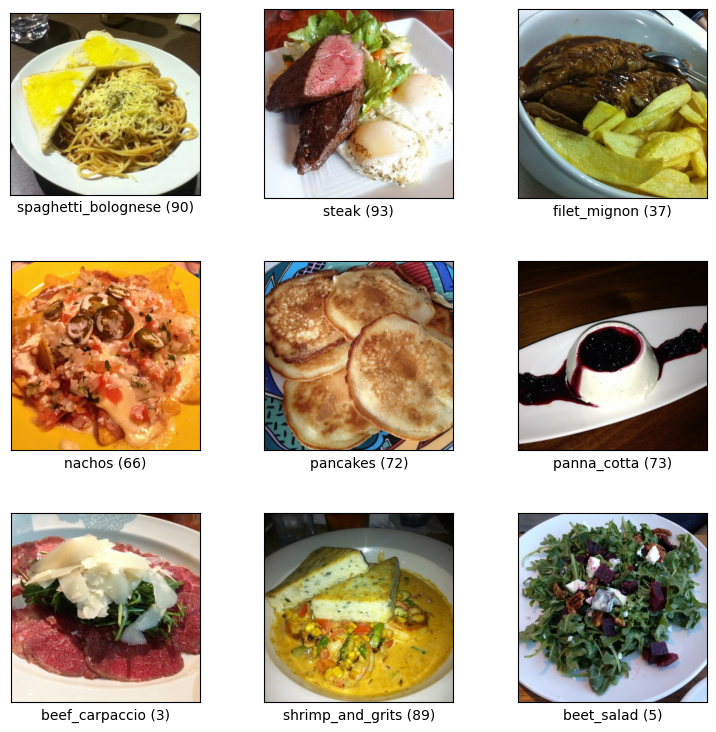

In [14]:
fig = tfds.show_examples(train_data, ds_info)

(-0.5, 511.5, 305.5, -0.5)

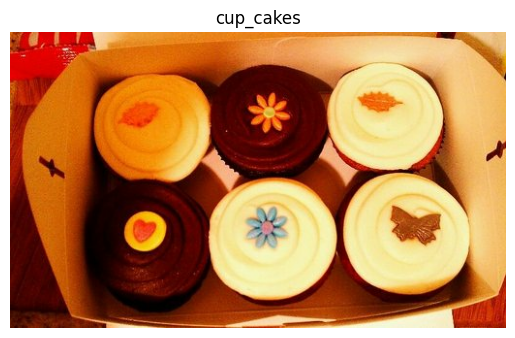

In [15]:
# Plot an single image
plt.imshow(image)
plt.title(class_names[label]) # add title to image by indexing on class_names list
plt.axis(False)

## Prepocessing of Data

Data is currently:
* In `uint8` data type
* Comprised of all differnet sized tensors (different sized images)
* Not scaled (the pixel values are between 0 & 255)

After Preprocessing Data
* In `float32` data type
* Have all of the same size tensors (batches require all tensors have the same shape, e.g. `(224, 224, 3)`)
* Scaled (values between 0 & 1), also called normalized

In [16]:
# Make a function for preprocessing images
def preprocess_img(image, label, img_shape=224, augment=False):
    """
    Prepares images for EfficientNetB0 by resizing, casting, and optionally augmenting.

    Standardizes input images to a fixed shape and float32 dtype. If 'augment' is True,
    applies a series of random transformations (flips, crops, etc.) via the data_augment
    helper function to improve model generalization.

    Args:
        image: The input image tensor (uint8).
        label: The integer label associated with the image.
        img_shape (int): The target height and width for resizing. Default is 224.
        augment (bool): Whether to apply data augmentation. Default is False.

    Returns:
        A tuple of (float32_image, label) where the image is resized to
        [img_shape, img_shape, 3].
    """
    if augment:
        image, label = data_augment(image, label, img_shape=img_shape)
    else:
        image = tf.image.resize(image, [img_shape, img_shape])

    return tf.cast(image, tf.float32), label

In [17]:
def data_augment(image, label, img_shape=224):
    """
    Applies custom geometric augmentations using native TensorFlow image operations.

    This function simulates complex transformations (Zoom, Pan, Flip) on the CPU,
    enabling high-performance parallel data loading without GPU overhead.

    Args:
        image (tf.Tensor): The input image tensor.
        label (tf.Tensor): The associated class label.
        img_shape (int): The target output dimensions.

    Returns:
        tuple: (Augmented float32 image, original label).
    """
    # 1. Random Horizontal Flip
    image = tf.image.random_flip_left_right(image)

    # 2. Random Zoom & Crop (Simulates Zoom/Height/Width shifts)
    # We define a random scale between 80% and 100% of the original size
    img_hd = tf.cast(tf.shape(image)[0], tf.float32)
    img_wd = tf.cast(tf.shape(image)[1], tf.float32)

    fraction = tf.random.uniform([], 0.8, 1.0)
    new_h = tf.cast(img_hd * fraction, tf.int32)
    new_w = tf.cast(img_wd * fraction, tf.int32)

    # Apply the crop and immediately resize back to target img_shape
    image = tf.image.random_crop(image, size=[new_h, new_w, 3])
    image = tf.image.resize(image, [img_shape, img_shape])

    # 3. Final Cast
    return tf.cast(image, tf.float32), label

`preprocess_img()` function above takes image and label as input (even though it does nothing to the label) because our dataset is currently in the tuple structure `(image, label)`.

Try function out on a target image.

The input image gets converted from `uint8` to `float32` and gets reshaped from its current shape to `(224, 224, 3)`.

Plot the preprocessed image to see

(224, 224, 3) <dtype: 'float32'>


(-0.5, 223.5, 223.5, -0.5)

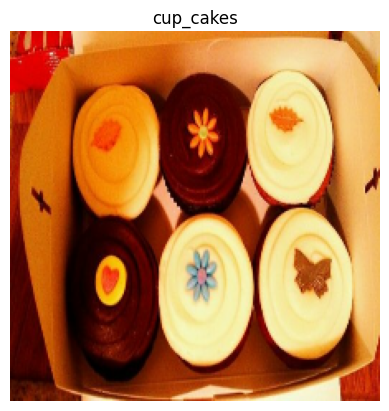

In [18]:
processed_img = preprocess_img(image, label)[0]
print(processed_img.shape, processed_img.dtype)
plt.imshow(processed_img/255.)
plt.title(class_names[label])
plt.axis(False)

## Prepare Dataset

In [19]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>)

In [20]:
# Map preprocessing function to training data (and paralellize)
processed_train_data = (train_data
              .map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
              .cache("m4_food101_cache") # Saves to SSD to keep 24GB RAM free
              .shuffle(buffer_size=1000)
              .batch(32)
              .prefetch(buffer_size=tf.data.AUTOTUNE))

processed_test_data = (test_data
             .map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
             .cache("m4_food101_test_cache")
             .batch(32)
             .prefetch(buffer_size=tf.data.AUTOTUNE))

In [21]:
processed_train_data, processed_test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

## Setup Mixed Precision Training

Mixed precision training involves using a mix of float16 and float32 tensors to make better use of your GPU's memory.

For a more detailed explanation : [TensorFlow mixed precision guide](https://www.tensorflow.org/guide/mixed_precision)

**Note:** If your GPU doesn't have a score of over 7.0+ (e.g. P100 in Google Colab), mixed precision won't work (see: ["Supported Hardware"](https://www.tensorflow.org/guide/mixed_precision#supported_hardware) in the mixed precision guide for more).

To handle 101,000 images efficiently on consumer hardware (Apple M4 / Google Colab), the pipeline was built for maximum throughput:
* **Parallel Mapping:** Used `num_parallel_calls=tf.data.AUTOTUNE` to offload augmentation to the CPU.
* **Prefetching:** Overlapped data preparation with model training to eliminate GPU starvation.
* **Deterministic Resizing:** Ensured all 101 classes were standardized to 224x224 before entering the network.

In [22]:
# Turn on mixed precision training
# mixed_precision.set_global_policy(policy="mixed_float16") # set global policy to mixed precision

As long as the GPU used has a compute capability of 7.0+ the cell above should run without error.

In [23]:
mixed_precision.global_policy() # should output "mixed_float16" (if your GPU is compatible with mixed precision)

<DTypePolicy "float32">

In [24]:
print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")   # bfloat16/float16
print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}") # float32

Compute dtype: float32
Variable dtype: float32


## Callbacks

In [25]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", # watch the val loss metric
                                                  patience=3) # if val loss decreases for 3 epochs in a row, stop training

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                 factor=0.2, # multiply the learning rate by 0.2 (reduce by 5x)
                                                 patience=2,
                                                 verbose=1, # print out when learning rate goes down
                                                 min_lr=1e-7)

## Models

### Experiment 1: Feature Extraction (Baseline)
Before fine-tuning, we evaluate the pre-trained weights of EfficientNetB0. This establishes the "floor" of our performance.
* **Model:** EfficientNetB0 (Frozen)
* **Epochs:** Early Stopping (patience=3)
* **Goal:** Reach >70% accuracy before unfreezing layers.

In [26]:
input_shape = (224, 224, 3)

# Create base model
base_model = tf.keras.applications.EfficientNetB0(include_top=False) # set include_top=False to remove output layer
base_model.trainable = False # freeze the base model

# Create functional model
inputs = layers.Input(shape=input_shape, name="input_layer")
# x = layers.Rescaling(1/255.)(x)
x = base_model(inputs, training=False) # set base_model to inference mode only
x = layers.GlobalAveragePooling2D(name="pooling_layer")(x)

# with mixed precision
x = layers.Dense(len(class_names))(x) # one output neuron per class 101
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)

# without mixed precision
# outputs = layers.Dense(len(class_names), activation="softmax", name="output_layer")(x) # one output neuron per class 101


model0 = tf.keras.Model(inputs, outputs)

# Compile the model
model0.compile(loss="sparse_categorical_crossentropy", # Use sparse_categorical_crossentropy when labels are *not* one-hot
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [27]:
model0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

#### Checking layer dtype policies

In [28]:
# Check the dtype_policy attributes of layers in our model
for layer in model0.layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy) # Check the dtype policy of layers

input_layer True float32 <DTypePolicy "float32">
efficientnetb0 False float32 <DTypePolicy "float32">
pooling_layer True float32 <DTypePolicy "float32">
dense True float32 <DTypePolicy "float32">
softmax_float32 True float32 <DTypePolicy "float32">


In [29]:
# Check the layers in the base model and see what dtype policy they're using
for layer in model0.layers[1].layers[:20]: # only check the first 20 layers to save output space
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer False float32 <DTypePolicy "float32">
rescaling False float32 <DTypePolicy "float32">
normalization False float32 <DTypePolicy "float32">
rescaling_1 False float32 <DTypePolicy "float32">
stem_conv_pad False float32 <DTypePolicy "float32">
stem_conv False float32 <DTypePolicy "float32">
stem_bn False float32 <DTypePolicy "float32">
stem_activation False float32 <DTypePolicy "float32">
block1a_dwconv False float32 <DTypePolicy "float32">
block1a_bn False float32 <DTypePolicy "float32">
block1a_activation False float32 <DTypePolicy "float32">
block1a_se_squeeze False float32 <DTypePolicy "float32">
block1a_se_reshape False float32 <DTypePolicy "float32">
block1a_se_reduce False float32 <DTypePolicy "float32">
block1a_se_expand False float32 <DTypePolicy "float32">
block1a_se_excite False float32 <DTypePolicy "float32">
block1a_project_conv False float32 <DTypePolicy "float32">
block1a_project_bn False float32 <DTypePolicy "float32">
block2a_expand_conv False float32 <DTypePol

#### Training

In [30]:
history_model0 = model0.fit(processed_train_data,
                            epochs=100, # fine-tune for a maximum of 100 epochs
                            steps_per_epoch=len(processed_train_data),
                            validation_data=processed_test_data,
                            validation_steps=int(0.15 * len(processed_test_data)), # validation during training on 15% of test data
                            callbacks=[create_tensorboard_callback("training_logs", "model0"), # track the model training logs
                                       create_model_checkpoint("model_checkpints", "model0"), # save only the best model during training
                                       early_stopping,
                                       reduce_lr]) # stop model after X epochs of no improvements

Saving TensorBoard log files to: training_logs/model0/20260402-184755
Epoch 1/100


2026-04-02 18:47:56.498851: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2335/2368 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.4746 - loss: 2.2930

2026-04-02 18:54:54.066875: W tensorflow/core/kernels/data/cache_dataset_ops.cc:302] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4759 - loss: 2.2858
Epoch 1: val_accuracy improved from None to 0.69094, saving model to model_checkpints/model0.weights.h5

Epoch 1: finished saving model to model_checkpints/model0.weights.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 450s 188ms/step - accuracy: 0.5678 - loss: 1.7781 - val_accuracy: 0.6909 - val_loss: 1.1559 - learning_rate: 0.0010
Epoch 2/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6672 - loss: 1.2877

2026-04-02 19:02:32.930531: W tensorflow/core/kernels/data/cache_dataset_ops.cc:302] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.



Epoch 2: val_accuracy improved from 0.69094 to 0.71584, saving model to model_checkpints/model0.weights.h5

Epoch 2: finished saving model to model_checkpints/model0.weights.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 448s 189ms/step - accuracy: 0.6724 - loss: 1.2678 - val_accuracy: 0.7158 - val_loss: 1.0432 - learning_rate: 0.0010
Epoch 3/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6999 - loss: 1.1431

2026-04-02 19:09:26.239162: W tensorflow/core/kernels/data/cache_dataset_ops.cc:302] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.



Epoch 3: val_accuracy improved from 0.71584 to 0.72987, saving model to model_checkpints/model0.weights.h5

Epoch 3: finished saving model to model_checkpints/model0.weights.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 413s 174ms/step - accuracy: 0.7045 - loss: 1.1336 - val_accuracy: 0.7299 - val_loss: 1.0016 - learning_rate: 0.0010
Epoch 4/100
1932/2368 ━━━━━━━━━━━━━━━━━━━━ 1:16 175ms/step - accuracy: 0.7201 - loss: 1.0495

KeyboardInterrupt: 

#### Evaluation

In [ ]:
# Evaluate model (unsaved version) on whole test dataset
results_model0 = model0.evaluate(processed_test_data)
results_model0

2026-04-02 12:48:22.494684: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: ALREADY_EXISTS: There appears to be a concurrent caching iterator running - cache lockfile already exists ('m4_food101_test_cache_0.lockfile'). If you are sure no other running TF computations are using this cache prefix, delete the lockfile and re-initialize the iterator. Lockfile contents: Created at: 1775151377
	 [[{{node IteratorGetNext}}]]
2026-04-02 12:48:22.494699: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: ALREADY_EXISTS: There appears to be a concurrent caching iterator running - cache lockfile already exists ('m4_food101_test_cache_0.lockfile'). If you are sure no other running TF computations are using this cache prefix, delete the lockfile and re-initialize the iterator. Lockfile contents: Created at: 1775151377
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/Shape/_6]]
2026-04-02 12:48:22.4

AlreadyExistsError: Graph execution error:

Detected at node IteratorGetNext defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 621, in shell_main

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 478, in dispatch_shell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 372, in execute_request

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 834, in execute_request

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 464, in do_execute

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/zmqshell.py", line 663, in run_cell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3123, in run_cell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3178, in _run_cell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3400, in run_cell_async

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3641, in run_ast_nodes

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code

  File "/var/folders/6z/tflx0kl94y543yzj6cg_86n40000gn/T/ipykernel_60456/986155918.py", line 1, in <module>

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 423, in fit

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 511, in evaluate

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 241, in function

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 154, in multi_step_on_iterator

Detected at node IteratorGetNext defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 621, in shell_main

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 478, in dispatch_shell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 372, in execute_request

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 834, in execute_request

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 464, in do_execute

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/ipykernel/zmqshell.py", line 663, in run_cell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3123, in run_cell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3178, in _run_cell

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3400, in run_cell_async

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3641, in run_ast_nodes

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code

  File "/var/folders/6z/tflx0kl94y543yzj6cg_86n40000gn/T/ipykernel_60456/986155918.py", line 1, in <module>

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 423, in fit

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 511, in evaluate

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 241, in function

  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py", line 154, in multi_step_on_iterator

2 root error(s) found.
  (0) ALREADY_EXISTS:  There appears to be a concurrent caching iterator running - cache lockfile already exists ('m4_food101_test_cache_0.lockfile'). If you are sure no other running TF computations are using this cache prefix, delete the lockfile and re-initialize the iterator. Lockfile contents: Created at: 1775151377
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/Shape/_6]]
  (1) ALREADY_EXISTS:  There appears to be a concurrent caching iterator running - cache lockfile already exists ('m4_food101_test_cache_0.lockfile'). If you are sure no other running TF computations are using this cache prefix, delete the lockfile and re-initialize the iterator. Lockfile contents: Created at: 1775151377
	 [[{{node IteratorGetNext}}]]
0 successful operations.
0 derived errors ignored. [Op:__inference_multi_step_on_iterator_46407]

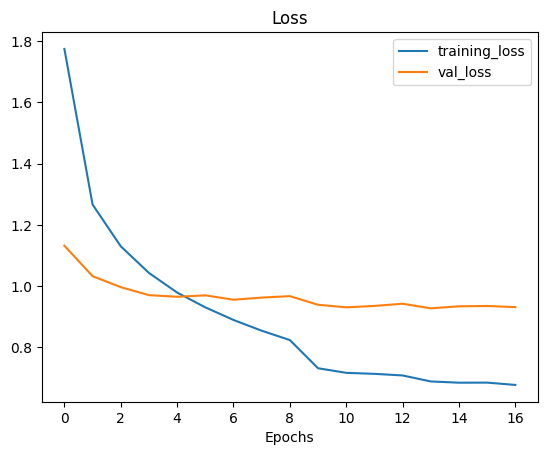

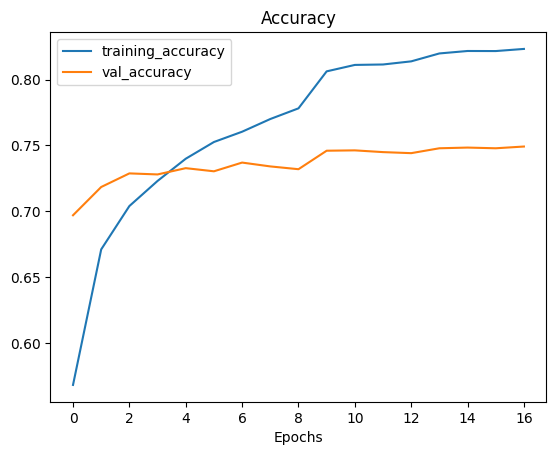

In [ ]:
plot_loss_curves(history_model0)

In [ ]:
# Good to save model to prevent re-training model again
model0.save("model0.keras")

### Experiment 2: Global Fine-Tuning
A key finding in this project was that **unfreezing all layers** outperformed the common practice of only unfreezing the top 20.
* **Insight:** Because food categories share many low-level features (textures, colors), the entire network benefited from being adapted to the Food101 distribution.
* **Learning Rate:** Dropped to $4e-6$ to ensure stable convergence without destroying pre-trained patterns.


In [ ]:
model1 = tf.keras.models.load_model("model0.keras")

In [ ]:
np.isclose(results_model0, model1.evaluate(processed_test_data))

790/790 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.7436 - loss: 0.9419


array([ True,  True])

 All of the layers in the base model is frozen by setting `base_model.trainable=False`


In [ ]:
# Are any of the layers in our model frozen?
for layer in model1.layers:
    layer.trainable = True # set all layers to trainable
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy) # make sure loaded model is using mixed precision dtype_policy ("mixed_float16")

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetb0 True float32 <DTypePolicy "mixed_float16">
pooling_layer True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


In [ ]:
for layer in model1.layers[1].layers[:20]:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
rescaling True float32 <DTypePolicy "mixed_float16">
normalization True float32 <DTypePolicy "mixed_float16">
rescaling_1 True float32 <DTypePolicy "mixed_float16">
stem_conv_pad True float32 <DTypePolicy "mixed_float16">
stem_conv True float32 <DTypePolicy "mixed_float16">
stem_bn True float32 <DTypePolicy "mixed_float16">
stem_activation True float32 <DTypePolicy "mixed_float16">
block1a_dwconv True float32 <DTypePolicy "mixed_float16">
block1a_bn True float32 <DTypePolicy "mixed_float16">
block1a_activation True float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze True float32 <DTypePolicy "mixed_float16">
block1a_se_reshape True float32 <DTypePolicy "mixed_float16">
block1a_se_reduce True float32 <DTypePolicy "mixed_float16">
block1a_se_expand True float32 <DTypePolicy "mixed_float16">
block1a_se_excite True float32 <DTypePolicy "mixed_float16">
block1a_project_conv True float32 <DTypePolicy "mixed_float16">
block1a_project

In [ ]:
# Compile the model
model1.compile(loss="sparse_categorical_crossentropy", # sparse_categorical_crossentropy for labels that are *not* one-hot
                        optimizer=tf.keras.optimizers.Adam(0.0001), # 10x lower learning rate than the default
                        metrics=["accuracy"])

#### Training

In [ ]:
history_model1 = model1.fit(processed_train_data,
                               epochs=100, # fine-tune for a maximum of 100 epochs
                               steps_per_epoch=len(processed_train_data),
                               validation_data=processed_test_data,
                               validation_steps=int(0.15 * len(processed_test_data)), # validation during training on 15% of test data
                               callbacks=[create_tensorboard_callback("training_logs", "model1"), # track the model training logs
                                          create_model_checkpoint("model_checkpints", "model1"), # save only the best model during training
                                          early_stopping, # stop model after X epochs of no improvements
                                          reduce_lr]) # reduce the learning rate after X epochs of no improvements

Saving TensorBoard log files to: training_logs/model1/20260326-003719
Epoch 1/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 470s 125ms/step - accuracy: 0.6887 - loss: 1.1592 - val_accuracy: 0.7852 - val_loss: 0.7907 - learning_rate: 1.0000e-04
Epoch 2/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 166s 70ms/step - accuracy: 0.8171 - loss: 0.6525 - val_accuracy: 0.7995 - val_loss: 0.7439 - learning_rate: 1.0000e-04
Epoch 3/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 165s 70ms/step - accuracy: 0.8731 - loss: 0.4561 - val_accuracy: 0.8130 - val_loss: 0.7132 - learning_rate: 1.0000e-04
Epoch 4/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 166s 70ms/step - accuracy: 0.9122 - loss: 0.3181 - val_accuracy: 0.8157 - val_loss: 0.7065 - learning_rate: 1.0000e-04
Epoch 5/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 166s 70ms/step - accuracy: 0.9392 - loss: 0.2264 - val_accuracy: 0.8175 - val_loss: 0.7142 - learning_rate: 1.0000e-04
Epoch 6/100
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9575 - loss: 0.1643
Epoch 6: ReduceLROnPlateau re

#### Evaluation

In [ ]:
results_model1 = model1.evaluate(processed_test_data)
results_model1

790/790 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.8276 - loss: 0.7019


[0.701875627040863, 0.8275643587112427]

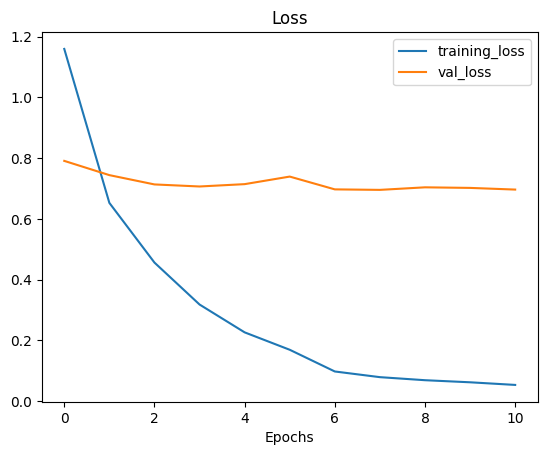

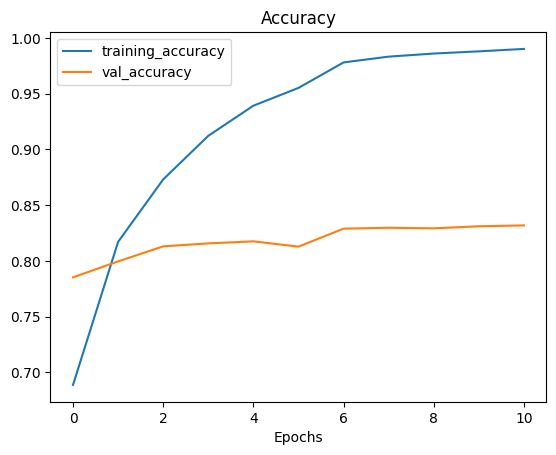

In [ ]:
plot_loss_curves(history_model1)

In [ ]:
model1.save("model1.keras")

### 3. Experiment 2: Global Fine-Tuning
A key finding in this project was that **unfreezing all layers** outperformed the common practice of only unfreezing the top 20.
* **Insight:** Because food categories share many low-level features (textures, colors), the entire network benefited from being adapted to the Food101 distribution.
* **Learning Rate:** Dropped to $4e-6$ to ensure stable convergence without destroying pre-trained patterns.

#### Prepare Dataset

In [ ]:
# Take one sample
train_one_sample = train_data.take(1)
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
for image , label in train_one_sample:
    print(image.shape, label)

(341, 512, 3) tf.Tensor(98, shape=(), dtype=int64)


(np.float64(-0.5), np.float64(511.5), np.float64(340.5), np.float64(-0.5))

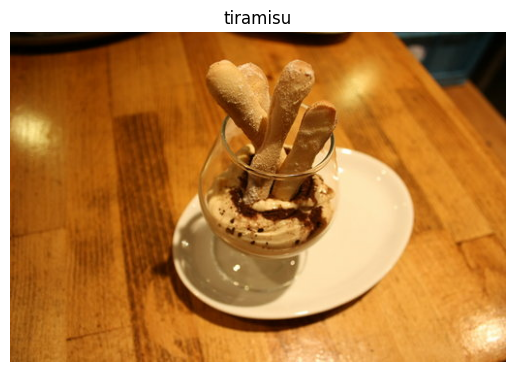

In [ ]:
# Plot an single image
plt.imshow(image)
plt.title(class_names[label]) # add title to image by indexing on class_names list
plt.axis(False)

(224, 224, 3) <dtype: 'float32'>


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

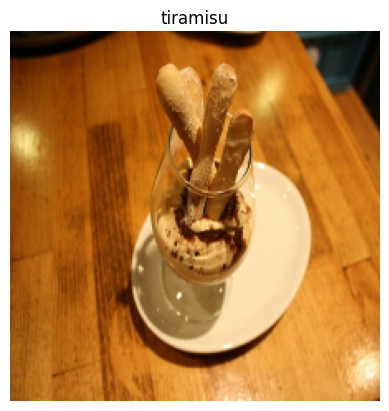

In [ ]:
processed_img = preprocess_img(image, label)[0]
print(processed_img.shape, processed_img.dtype)
plt.imshow(processed_img/255.)
plt.title(class_names[label])
plt.axis(False)

In [ ]:
# Map preprocessing function to training data (and paralellize)

processed_train_data = (train_data
              .map(map_func=lambda x, y: preprocess_img(x, y, augment=True), num_parallel_calls=tf.data.AUTOTUNE)
              # .cache("m4_food101_cache") # Saves to SSD to keep 24GB RAM free
              .shuffle(buffer_size=1000)
              .batch(32)
              .prefetch(buffer_size=tf.data.AUTOTUNE))

processed_test_data = (test_data
             .map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
            #  .cache("m4_food101_test_cache")
             .batch(32)
             .prefetch(buffer_size=tf.data.AUTOTUNE))

In [ ]:
model2 = tf.keras.models.load_model("model0.keras")

In [ ]:
np.isclose(results_model0, model2.evaluate(processed_test_data))

790/790 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.7436 - loss: 0.9419


array([ True,  True])

In [ ]:
# Are any of the layers in our model frozen?
for layer in model2.layers:
    layer.trainable = True # set all layers to trainable
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy) # make sure loaded model is using mixed precision dtype_policy ("mixed_float16")

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetb0 True float32 <DTypePolicy "mixed_float16">
pooling_layer True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


In [ ]:
for layer in model2.layers[1].layers[:20]:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
rescaling True float32 <DTypePolicy "mixed_float16">
normalization True float32 <DTypePolicy "mixed_float16">
rescaling_1 True float32 <DTypePolicy "mixed_float16">
stem_conv_pad True float32 <DTypePolicy "mixed_float16">
stem_conv True float32 <DTypePolicy "mixed_float16">
stem_bn True float32 <DTypePolicy "mixed_float16">
stem_activation True float32 <DTypePolicy "mixed_float16">
block1a_dwconv True float32 <DTypePolicy "mixed_float16">
block1a_bn True float32 <DTypePolicy "mixed_float16">
block1a_activation True float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze True float32 <DTypePolicy "mixed_float16">
block1a_se_reshape True float32 <DTypePolicy "mixed_float16">
block1a_se_reduce True float32 <DTypePolicy "mixed_float16">
block1a_se_expand True float32 <DTypePolicy "mixed_float16">
block1a_se_excite True float32 <DTypePolicy "mixed_float16">
block1a_project_conv True float32 <DTypePolicy "mixed_float16">
block1a_project

In [ ]:
# Compile the model
model2.compile(loss="sparse_categorical_crossentropy", # sparse_categorical_crossentropy for labels that are *not* one-hot
                        optimizer=tf.keras.optimizers.Adam(0.0001), # 10x lower learning rate than the default
                        metrics=["accuracy"])

#### Training

In [ ]:
history_model2 = model2.fit(processed_train_data,
                                     epochs=100, # fine-tune for a maximum of 100 epochs
                                     steps_per_epoch=len(processed_train_data),
                                     validation_data=processed_test_data,
                                     validation_steps=int(0.15 * len(processed_test_data)), # validation during training on 15% of test data
                                     callbacks=[create_tensorboard_callback("training_logs", "model2"), # track the model training logs
                                                create_model_checkpoint("model_checkpints", "model2"), # save only the best model during training
                                                early_stopping, # stop model after X epochs of no improvements
                                                reduce_lr]) # reduce the learning rate after X epochs of no improvements

Saving TensorBoard log files to: training_logs/model2/20260326-014829
Epoch 1/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 368s 107ms/step - accuracy: 0.6827 - loss: 1.1950 - val_accuracy: 0.7842 - val_loss: 0.7910 - learning_rate: 1.0000e-04
Epoch 2/100
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7935 - loss: 0.7469
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 170s 71ms/step - accuracy: 0.7973 - loss: 0.7287 - val_accuracy: 0.8030 - val_loss: 0.7253 - learning_rate: 1.0000e-04
Epoch 3/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 173s 73ms/step - accuracy: 0.8592 - loss: 0.5040 - val_accuracy: 0.8175 - val_loss: 0.6783 - learning_rate: 2.0000e-05
Epoch 4/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 172s 72ms/step - accuracy: 0.8737 - loss: 0.4573 - val_accuracy: 0.8162 - val_loss: 0.6666 - learning_rate: 2.0000e-05
Epoch 5/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 171s 72ms/step - accuracy: 0.8823 - loss: 0.4200 - val_accuracy: 0.8175 - val_loss:

#### Evaluation

In [ ]:
results_model2 = model2.evaluate(processed_test_data)
results_model2

790/790 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.8248 - loss: 0.6634


[0.6633844971656799, 0.8247524499893188]

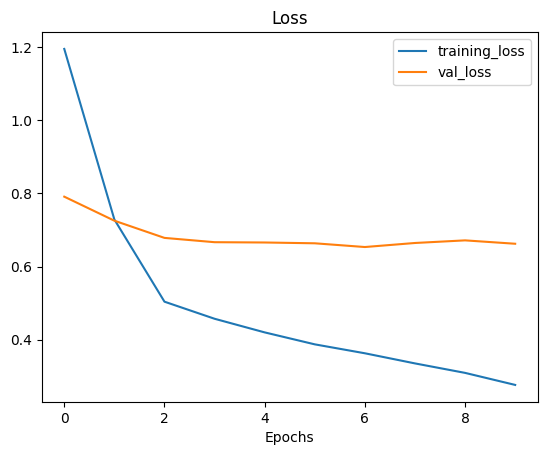

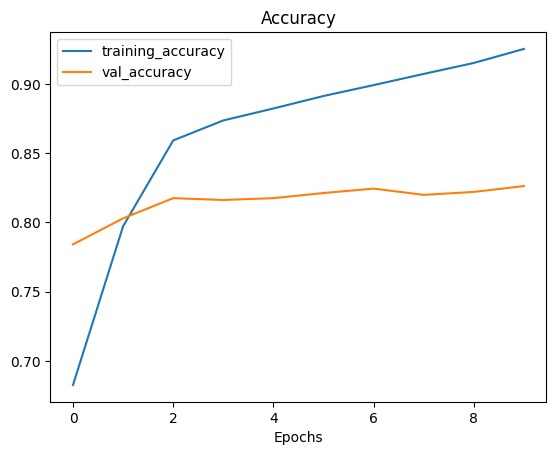

In [ ]:
plot_loss_curves(history_model2)

In [ ]:
model2.save("model2.keras")

### 4. Experiment 3: Regularization & Augmentation
At this stage, the model began to overfit (96% Training vs 83% Validation). To close this gap, two techniques were introduced:
1. **CPU-Side Augmentation:** Random flips, brightness shifts, and crops to simulate real-world restaurant lighting and angles.
2. **Dropout (0.3):** Added to the final dense layer to force the model to learn redundant, robust features.

In [ ]:
input_shape = (224, 224, 3)

# Create base models
base_model = tf.keras.applications.EfficientNetB0(include_top=False) # set include_top=False to remove output layer
base_model.trainable = True # freeze the base model

# Create functional model
inputs = layers.Input(shape=input_shape, name="input_layer")
# x = layers.Rescaling(1/255.)(x)
x = base_model(inputs, training=False) # set base_model to inference mode only
x = layers.GlobalAveragePooling2D(name="pooling_layer")(x)
x = layers.Dropout(0.3)(x)

# with mixed precision
x = layers.Dense(len(class_names))(x) # one output neuron per class 101
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)

# without mixed precision
# outputs = layers.Dense(len(class_names), activation="softmax", name="output_layer")(x) # one output neuron per class 101

model3 = tf.keras.Model(inputs, outputs)

# Compile the model
model3.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

#### Training

In [ ]:
history_model3 = model3.fit(processed_train_data,
                            epochs=100, # fine-tune for a maximum of 100 epochs
                            steps_per_epoch=len(processed_train_data),
                            validation_data=processed_test_data,
                            validation_steps=int(0.15 * len(processed_test_data)), # validation during training on 15% of test data
                            callbacks=[create_tensorboard_callback("training_logs", "model3"), # track the model training logs
                                       create_model_checkpoint("model_checkpints", "model3"), # save only the best model during training
                                       early_stopping, # stop model after X epochs of no improvements
                                       reduce_lr])

Saving TensorBoard log files to: training_logs/model3/20260326-022044
Epoch 1/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 368s 107ms/step - accuracy: 0.4849 - loss: 2.1946 - val_accuracy: 0.7569 - val_loss: 0.9053 - learning_rate: 1.0000e-04
Epoch 2/100
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6843 - loss: 1.2162
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 175s 73ms/step - accuracy: 0.6993 - loss: 1.1489 - val_accuracy: 0.8077 - val_loss: 0.7009 - learning_rate: 1.0000e-04
Epoch 3/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 177s 74ms/step - accuracy: 0.7645 - loss: 0.8843 - val_accuracy: 0.8260 - val_loss: 0.6226 - learning_rate: 2.0000e-05
Epoch 4/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 174s 73ms/step - accuracy: 0.7794 - loss: 0.8248 - val_accuracy: 0.8332 - val_loss: 0.6010 - learning_rate: 2.0000e-05
Epoch 5/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 173s 73ms/step - accuracy: 0.7903 - loss: 0.7803 - val_accuracy: 0.8374 - val_loss:

#### Evaluation

In [ ]:
results_model3 = model3.evaluate(processed_test_data)
results_model3

790/790 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8481 - loss: 0.5551


[0.5551345944404602, 0.8481188416481018]

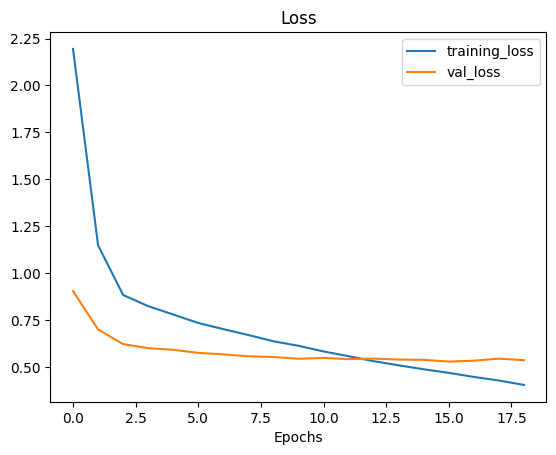

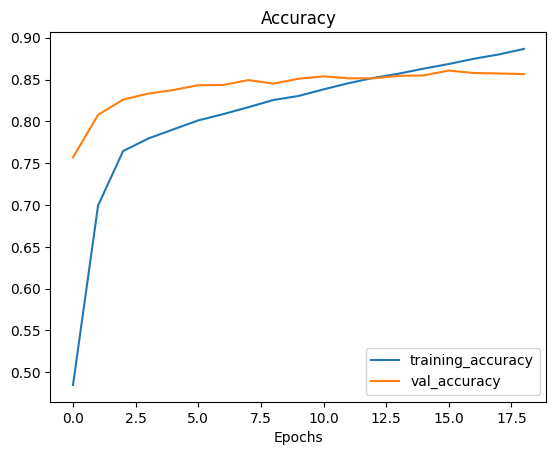

In [ ]:
plot_loss_curves(history_model3)

In [ ]:
model3.save("model3.keras")

## Making Predictions with our model

In [ ]:
model3 = tf.keras.models.load_model("model3.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 428 variables whereas the saved optimizer has 432 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
predict_prob = model3.predict(processed_test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step


In [ ]:
len(predict_prob)

25250

In [ ]:
predict_prob.shape

(25250, 101)

In [ ]:
predict_prob[0]

array([1.71595573e-04, 6.64050003e-06, 5.42062735e-05, 5.31578298e-05,
       1.69430888e-04, 8.28286516e-04, 2.88970978e-06, 5.77022765e-05,
       1.96189038e-03, 2.47364515e-04, 6.08268347e-05, 1.16522296e-03,
       3.16800542e-05, 1.41564800e-04, 1.66942154e-05, 9.42667127e-01,
       1.54268564e-04, 1.87331862e-05, 1.57464950e-04, 5.05258031e-05,
       9.47499302e-06, 3.12498778e-05, 7.45488424e-03, 3.66062341e-05,
       1.94443259e-04, 9.87316962e-05, 3.16229591e-04, 2.12099258e-04,
       1.46465209e-05, 9.96857125e-06, 2.73406768e-04, 2.03316472e-06,
       1.20243922e-05, 9.09559021e-05, 1.16448027e-04, 7.64430952e-05,
       3.39214203e-05, 2.95867867e-05, 1.17132346e-04, 3.94323491e-04,
       3.51351773e-05, 5.62556233e-05, 3.11233975e-06, 4.02826809e-05,
       3.98912089e-05, 1.48358638e-04, 5.61374736e-06, 5.91861317e-05,
       8.96332494e-05, 1.55303569e-05, 1.17361349e-04, 9.54140996e-05,
       1.77362235e-05, 1.33618814e-05, 7.29425155e-05, 1.94414224e-05,
      

In [ ]:
sum(predict_prob[0])

np.float32(0.99999976)

In [ ]:
print(f"The class with the highest predicted probability by the model for sample 0: {predict_prob[0].argmax()}")

The class with the highest predicted probability by the model for sample 0: 15


In [ ]:
class_names[predict_prob[0].argmax()]

'ceviche'

In [ ]:
# 1. Create empty lists to catch everything in order
all_y_true = []
all_y_pred = []
all_y_pred_probs = []

# 2. Loop through the test data once to ensure perfect alignment
for images, labels in processed_test_data:
    # Get predictions for this batch
    preds = model3.predict(images, verbose=0)

    # Store the true labels and the predicted labels
    all_y_true.extend(labels.numpy())
    all_y_pred.extend(preds.argmax(axis=1))
    all_y_pred_probs.extend(preds.max(axis=1))


# 3. Convert to numpy arrays
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

Evaluating... this may take a minute.


### Evaluating models predictions

 Check model's predictions array `(pred_classes)` is in the same order as our test labels array `(y_labels)` is to find the accuracy score

In [ ]:
# Let's try scikit-learn's accuracy score dunction and see what it comes up with
sklearn_accuracy = accuracy_score(y_true=all_y_true, y_pred=all_y_pred)
sklearn_accuracy

0.8481584158415841

In [ ]:
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
make_confusion_matrix(y_true=all_y_true,
                      y_pred=all_y_pred,
                      classes=class_names,
                      figsize=(100,100),
                      text_size=20)

Scikit-learn has a helpful function for acquiring many different classification metrics per class (e.g. precision, recall and F1) called classification_report, let's try it out.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(all_y_true, all_y_pred))

              precision    recall  f1-score   support

           0       0.67      0.68      0.67       250
           1       0.83      0.86      0.84       250
           2       0.88      0.90      0.89       250
           3       0.89      0.88      0.88       250
           4       0.79      0.82      0.80       250
           5       0.75      0.76      0.75       250
           6       0.86      0.88      0.87       250
           7       0.90      0.94      0.92       250
           8       0.64      0.63      0.64       250
           9       0.83      0.77      0.80       250
          10       0.80      0.80      0.80       250
          11       0.86      0.88      0.87       250
          12       0.92      0.91      0.92       250
          13       0.84      0.85      0.85       250
          14       0.86      0.83      0.84       250
          15       0.75      0.68      0.71       250
          16       0.80      0.75      0.77       250
          17       0.90    

In [ ]:
# Get a dictionary of the classification report
classification_report_dict = classification_report(all_y_true, all_y_pred, output_dict=True)
classification_report_dict

{'0': {'precision': 0.6733067729083665,
  'recall': 0.676,
  'f1-score': 0.6746506986027944,
  'support': 250.0},
 '1': {'precision': 0.8326848249027238,
  'recall': 0.856,
  'f1-score': 0.8441814595660749,
  'support': 250.0},
 '2': {'precision': 0.8793774319066148,
  'recall': 0.904,
  'f1-score': 0.8915187376725838,
  'support': 250.0},
 '3': {'precision': 0.8870967741935484,
  'recall': 0.88,
  'f1-score': 0.8835341365461847,
  'support': 250.0},
 '4': {'precision': 0.7884615384615384,
  'recall': 0.82,
  'f1-score': 0.803921568627451,
  'support': 250.0},
 '5': {'precision': 0.7480314960629921,
  'recall': 0.76,
  'f1-score': 0.753968253968254,
  'support': 250.0},
 '6': {'precision': 0.8627450980392157,
  'recall': 0.88,
  'f1-score': 0.8712871287128713,
  'support': 250.0},
 '7': {'precision': 0.9,
  'recall': 0.936,
  'f1-score': 0.9176470588235294,
  'support': 250.0},
 '8': {'precision': 0.6448979591836734,
  'recall': 0.632,
  'f1-score': 0.6383838383838384,
  'support': 250

In [ ]:
# Create empty dicitonary
class_f1_scores = {}
# Loop through  classification report dictionary items
for k, v in classification_report_dict.items():
  if k == "accuracy": # stop once we get to accuracy key
    break
  else:
    # Add class names and f1-scores to new dictionary
    class_f1_scores[class_names[int(k)]] = v["f1-score"]
class_f1_scores

{'apple_pie': 0.6746506986027944,
 'baby_back_ribs': 0.8441814595660749,
 'baklava': 0.8915187376725838,
 'beef_carpaccio': 0.8835341365461847,
 'beef_tartare': 0.803921568627451,
 'beet_salad': 0.753968253968254,
 'beignets': 0.8712871287128713,
 'bibimbap': 0.9176470588235294,
 'bread_pudding': 0.6383838383838384,
 'breakfast_burrito': 0.7991718426501035,
 'bruschetta': 0.8,
 'caesar_salad': 0.8695652173913043,
 'cannoli': 0.9153225806451613,
 'caprese_salad': 0.8469184890656064,
 'carrot_cake': 0.8438133874239351,
 'ceviche': 0.7130801687763713,
 'cheesecake': 0.7711340206185567,
 'cheese_plate': 0.8879837067209776,
 'chicken_curry': 0.7793240556660039,
 'chicken_quesadilla': 0.8300395256916996,
 'chicken_wings': 0.9076923076923077,
 'chocolate_cake': 0.7605633802816901,
 'chocolate_mousse': 0.6731141199226306,
 'churros': 0.9047619047619048,
 'clam_chowder': 0.8941176470588236,
 'club_sandwich': 0.8893280632411067,
 'crab_cakes': 0.7784431137724551,
 'creme_brulee': 0.9163346613545

In [ ]:
# Trun f1-scores into dataframe for visualization
f1_scores = pd.DataFrame({"class_names": list(class_f1_scores.keys()),
                          "f1-score": list(class_f1_scores.values())}).sort_values("f1-score", ascending=False)

In [ ]:
f1_scores[:10]

,class_names,f1-score
33,edamame,0.992032
63,macarons,0.960474
64,miso_soup,0.951020
45,frozen_yogurt,0.949416
90,spaghetti_bolognese,0.947368
91,spaghetti_carbonara,0.941884
88,seaweed_salad,0.941884
69,oysters,0.940239
54,hot_and_sour_soup,0.936759
75,pho,0.925490


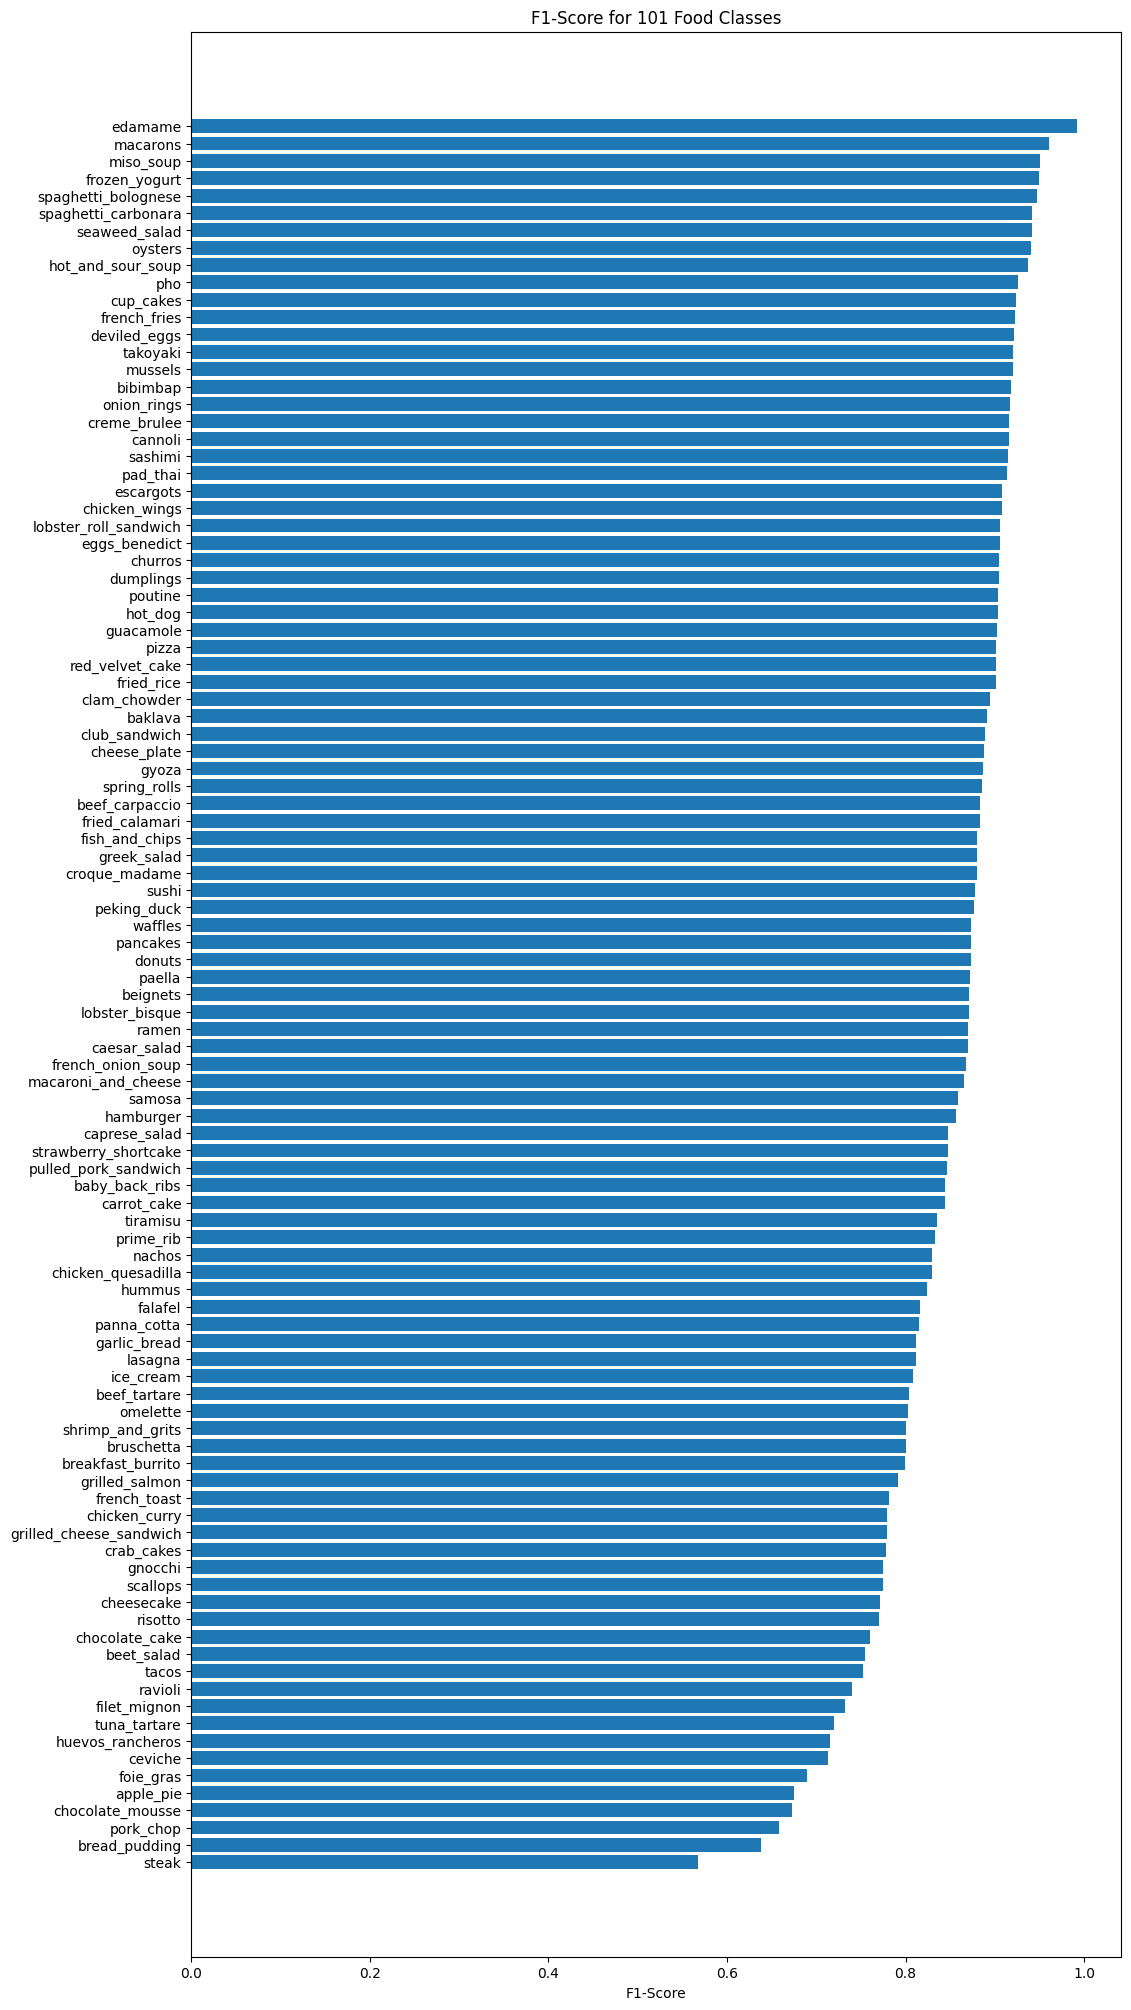

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,25))
scores = ax.barh(range(len(f1_scores)), f1_scores["f1-score"].values) # get f1_scores
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(f1_scores["class_names"])
ax.set_xlabel("F1-Score")
ax.set_title("F1-Score for 101 Food Classes")
ax.invert_yaxis(); # reverse the order

### Visiulize predictions

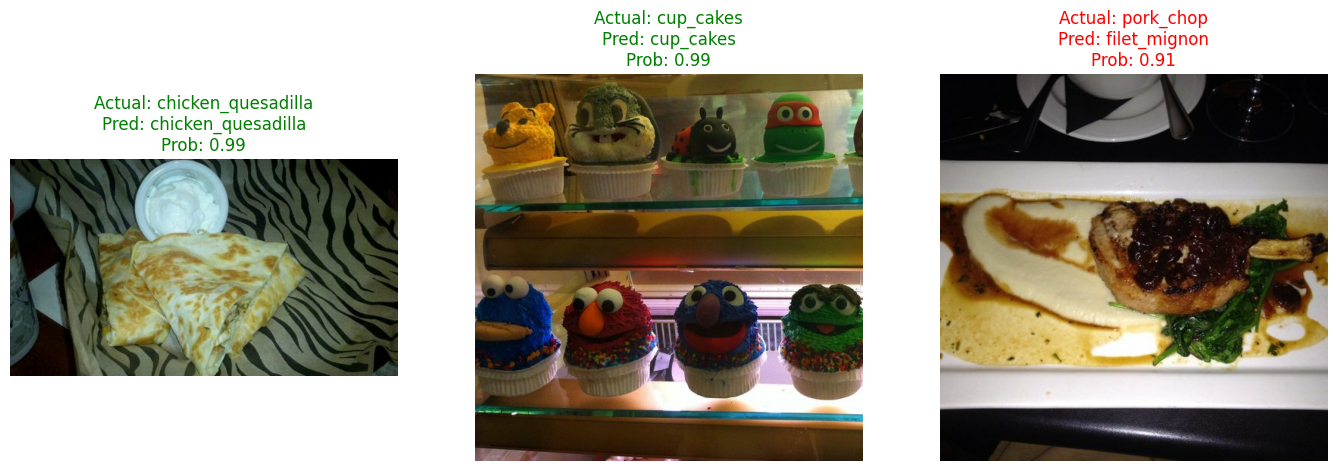

In [ ]:
plt.figure(figsize=(17, 10))

for i in range(3):

  # 1. Shuffle with a buffer of 1000, then take 1 to make it random
  random_sample = test_data.shuffle(1000).take(1)

  for image, label in random_sample:
    # 2. Match your model's preprocessing (224, 224)
    img = tf.image.resize(image, [224, 224])
    img = tf.cast(img, tf.float32)

    # 3. Add batch dimension (1, 224, 224, 3)
    img_expanded = tf.expand_dims(img, axis=0)

    # 4. Predict using your best model (model3)
    pred_prob = model3.predict(img_expanded, verbose=0)
    pred_class = class_names[pred_prob.argmax()]
    actual_class = class_names[label.numpy()]

    # 5. Plot
    plt.subplot(1, 3, i+1)
    plt.imshow(image.numpy())
    title_color = "green" if actual_class == pred_class else "red"
    plt.title(f"Actual: {actual_class}\nPred: {pred_class}\nProb: {pred_prob.max():.2f}",
              c=title_color)
    plt.axis(False)

### Finding the most wrong predictions

In [ ]:
#Create the DataFrame using the full evaluation arrays
pred_df = pd.DataFrame({
    "y_true": all_y_true,
    "y_pred": all_y_pred,
    "pred_conf": all_y_pred_probs,

    # Since we didn't store all 25,250 raw probabilities to save memory,
    # we'll label this as the final class names for now:
    "y_true_classname": [class_names[i] for i in all_y_true],
    "y_pred_classname": [class_names[i] for i in all_y_pred]
})

pred_df

,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname
0,42,100,0.964984,french_toast,waffles
1,1,1,0.970479,baby_back_ribs,baby_back_ribs
2,75,75,0.474049,pho,pho
3,61,61,0.999329,lobster_roll_sandwich,lobster_roll_sandwich
4,74,74,0.919116,peking_duck,peking_duck
...,...,...,...,...,...
25245,38,38,0.999976,fish_and_chips,fish_and_chips
25246,86,86,0.852577,sashimi,sashimi
25247,76,76,0.472522,pizza,pizza
25248,31,31,0.999999,donuts,donuts


In [ ]:
# Add a column to easily see if the prediction was correct
pred_df["pred_correct"] = pred_df["y_true"] == pred_df["y_pred"]
pred_df.head()

,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
0,42,100,0.964984,french_toast,waffles,False
1,1,1,0.970479,baby_back_ribs,baby_back_ribs,True
2,75,75,0.474049,pho,pho,True
3,61,61,0.999329,lobster_roll_sandwich,lobster_roll_sandwich,True
4,74,74,0.919116,peking_duck,peking_duck,True


In [ ]:
# Sort our DataFrame to have most predictions at the top
top_100_wrong = pred_df[pred_df["pred_correct"] == False].sort_values("pred_conf", ascending=False)[:100]
top_100_wrong.head(20)

,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
2932,14,67,0.999996,carrot_cake,omelette,False
13854,46,10,0.999984,garlic_bread,bruschetta,False
16291,65,69,0.999935,mussels,oysters,False
22293,64,54,0.999701,miso_soup,hot_and_sour_soup,False
11736,87,69,0.999597,scallops,oysters,False
15519,56,66,0.999394,huevos_rancheros,nachos,False
3120,21,83,0.999316,chocolate_cake,red_velvet_cake,False
9907,54,75,0.999272,hot_and_sour_soup,pho,False
23368,88,15,0.999234,seaweed_salad,ceviche,False
19662,46,11,0.999086,garlic_bread,caesar_salad,False


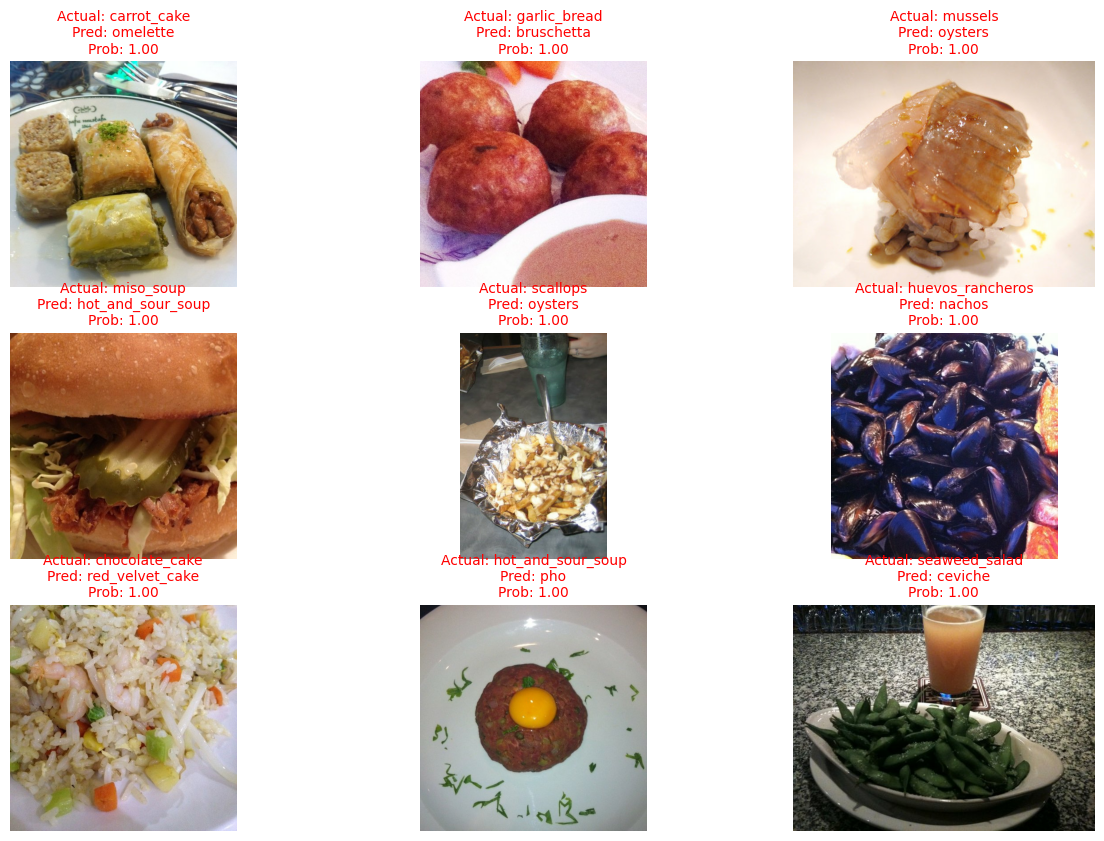

In [ ]:
# Visualize the test data samples which have the wrong prediction but highest pred probability
test_data_list = list(test_data.as_numpy_iterator())

images_to_view = 9
start_index = 0
plt.figure(figsize=(15, 10))

# 2. Loop through our 'Most Confident Mistakes'
for i, row in enumerate(top_100_wrong[start_index:start_index+images_to_view].itertuples()):
    plt.subplot(3, 3, i+1)

    # row[0] is the original index from the test set
    idx = row.Index
    img, label = test_data_list[idx]

    # Display the image (it's already a numpy array from the iterator)
    plt.imshow(img)

    # Use the class names we stored in the DataFrame
    plt.title(f"Actual: {row.y_true_classname}\nPred: {row.y_pred_classname}\nProb: {row.pred_conf:.2f}",
              fontsize=10,
              color="red") # It's a mistake, so we keep it red
    plt.axis(False)

plt.show()

### Making prediction on Custom images

In [ ]:
# Get the custom food images filepaths
custom_food_images = ["custom_food_images/" + img_path for img_path in os.listdir("custom_food_images")]
custom_food_images

['custom_food_images/hamburger.jpeg',
 'custom_food_images/chicken_wings.jpeg',
 'custom_food_images/steak.jpeg',
 'custom_food_images/sushi.jpeg',
 'custom_food_images/ramen.jpeg',
 'custom_food_images/pizza-dad.jpeg']

In [ ]:
# Make predictions on and plot custom food images
for img in custom_food_images:
  img = load_and_prep_images(img, scale=False) # don't need to scale for our EfficientNetB0 model
  pred_prob = model3.predict(tf.expand_dims(img, axis=0)) # make prediction on image with shape [1, 224, 224, 3] (same shape as model was trained on)
  pred_class = class_names[pred_prob.argmax()] # get the index with the highet prediction probability
  # Plot the appropriate information
  plt.figure()
  plt.imshow(img/225.)
  plt.title(f"pred: {pred_class}, prob: {pred_prob.max():.2f}")
  plt.axis(False)

## Final Results & Benchmarking
The final model achieved a **Validation Accuracy of 86.15%**.

| Metric | Result |
| :--- | :--- |
| **Final Accuracy** | **86.15%** |
| **Benchmark (DeepFood)** | 77.4% |
| **Improvement** | **+8.75%** |

### Key Takeaways:
* **Architecture:** EfficientNetB0 proved to be a highly efficient "pound-for-pound" winner, beating much larger models from previous years.
* **Optimization:** Moving augmentation to the `tf.data` pipeline reduced training time by nearly 50% compared to Keras Layers.

## Model Limitations & Error Analysis
The model excels at identifying visually distinct foods (e.g., Edamame, Hot and Sour Soup) but shows confusion in categories with high "intra-class variance" like **Steak vs. Pork Chops**.

**Future Work:** * Implementing **Label Smoothing** to handle the known "noisy" labels in the Food101 dataset.
* Deploying via **TensorFlow Lite** for real-time inference on the Apple M4 NPU.